# Three-Stage Multimodal Model — MHC Class I




In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt

DATA_PATH = "/Users/Akhil/vscode/Peptide/Data/ML_Ready/IEDB_ML_ready_with_seq_with_HLA.csv"

CACHE_DIR = "/Users/Akhil/vscode/Peptide/Methods/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MAX_PEP_LEN = 11          
N_TOP_BIO   = 8           
RANDOM_STATE = 42
USE_ESM2 = False          

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Device:", device)
print("CHANGE DEVICE DEPENEDENT ON YOUR COMPUTER")

Device: mps
CHANGE DEVICE DEPENEDENT ON YOUR COMPUTER


## 1. Load class I data, drop leaks, split

In [2]:
hla_library = {
    # HLA-A*24:02  →  IMGT/HLA source allele: A*24:02:01:01
    "HLA-A*24:02": (
        "GSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DEETGKVKAHSQTDRENLRIALRYYNQSEAGSHTLQMMFGCDVGSDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQITKRKWEAAHVAEQQRAYLEGTCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*02:01  →  IMGT/HLA source allele: A*02:01:01:01
    "HLA-A*02:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*32:01  →  IMGT/HLA source allele: A*32:01:01:01
    "HLA-A*32:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAHSQTDRESLRIALRYYNQSEAGSHTIQMMYGCDVGPDGRLLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:10  →  IMGT/HLA source allele: B*15:10:01:01
    "HLA-B*15:10": (
        "GSHSMRYFYTAMSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQICKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*03:04  →  IMGT/HLA source allele: C*03:04:01:01
    "HLA-C*03:04": (
        "GSHSMRYFYTAVSRPGRGEPHFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLKNGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-C*14:02  →  IMGT/HLA source allele: C*14:02:01:01
    "HLA-C*14:02": (
        "CSHSMRYFSTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVSLRNLRGYYNQSEAGSHTLQWMFGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQWDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*44:02  →  IMGT/HLA source allele: B*44:02:01:01
    "HLA-B*44:02": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQDRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*57:01  →  IMGT/HLA source allele: B*57:01:01:01
    "HLA-B*57:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DGETRNMKASAQTYRENLRIALRYYNQSEAGSHIIQVMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*03:01  →  IMGT/HLA source allele: A*03:01:01:01
    "HLA-A*03:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHEAEQLRAYLDGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*05:01  →  IMGT/HLA source allele: C*05:01:01:01
    "HLA-C*05:01": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVQFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQTDRVNLRKLRGYYNQSEAGSHTLQRMYGCDLGPDGRLLRGYNQFAYDG"
        "KDYIALNEDLRSWTAADKAAQITQRKWEAAREAEQRRAYLEGTCVEWLRRYLENGKKTLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*27:05  →  IMGT/HLA source allele: B*27:05:02:01
    "HLA-B*27:05": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRETQICKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*51:01  →  IMGT/HLA source allele: B*51:01:01:01
    "HLA-B*51:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRENLRIALRYYNQSEAGSHTWQTMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*40:01  →  IMGT/HLA source allele: B*40:01:01
    "HLA-B*40:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQISQRKLEAARVAEQLRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*40:02  →  IMGT/HLA source allele: B*40:02:01:01
    "HLA-B*40:02": (
        "GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHNQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*07:02  →  IMGT/HLA source allele: B*07:02:01:01
    "HLA-B*07:02": (
        "GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREEPRAPWIEQEGPEYW"
        "DRNTQIYKAQAQTDRESLRNLRGYYNQSEAGSHTLQSMYGCDVGPDGRLLRGHDQYAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQRRAYLEGECVEWLRRYLENGKDKLE"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*18:01  →  IMGT/HLA source allele: B*18:01:01:01
    "HLA-B*18:01": (
        "GSHSMRYFHTSVSRPGRGEPRFISVGYVDGTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGTCVEWLRRHLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*25:01  →  IMGT/HLA source allele: A*25:01:01:01
    "HLA-A*25:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAHSQTDRESLRIALRYYNQSEDGSHTIQRMYGCDVGPDGRFLRGYQQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWETAHEAEQWRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWASVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*44:03  →  IMGT/HLA source allele: B*44:03:01:01
    "HLA-B*44:03": (
        "GSHSMRYFYTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRTALRYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQDAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVESLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEVTLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*30:01  →  IMGT/HLA source allele: A*30:01:01:01
    "HLA-A*30:01": (
        "GSHSMRYFSTSVSRPGSGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQERPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQIMYGCDVGSDGRFLRGYEQHAYDG"
        "KDYIALNEDLRSWTAADMAAQITQRKWEAARWAEQLRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*11:01  →  IMGT/HLA source allele: A*11:01:01:01
    "HLA-A*11:01": (
        "GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DQETRNVKAQSQTDRVDLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAAHAAEQQRAYLEGRCVEWLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-C*12:03  →  IMGT/HLA source allele: C*12:03:01:01
    "HLA-C*12:03": (
        "CSHSMRYFYTAVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRGEPRAPWVEQEGPEYW"
        "DRETQKYKRQAQADRVSLRNLRGYYNQSEAGSHTLQWMYGCDLGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLRSWTAADTAAQITQRKWEAAREAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RAEHPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPEPLTLRW"
    ),
 
    # HLA-B*49:01  →  IMGT/HLA source allele: B*49:01:01:01
    "HLA-B*49:01": (
        "GSHSMRYFHTAMSRPGRGEPRFITVGYVDDTLFVRFDSDATSPRKEPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRENLRIALRYYNQSEAGSHTWQRMYGCDLGPDGRLLRGYNQLAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*01:01  →  IMGT/HLA source allele: A*01:01:01:01
    "HLA-A*01:01": (
        "GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW"
        "DQETRNMKAHSQTDRANLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG"
        "KDYIALNEDLRSWTAADMAAQITKRKWEAVHAAEQRRVYLEGRCVDGLRRYLENGKETLQ"
        "RTDPPKTHMTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:02  →  IMGT/HLA source allele: B*15:02:01:01
    "HLA-B*15:02": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRNTQISKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDVGPDGRLLRGYDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*35:01  →  IMGT/HLA source allele: B*35:01:01:01
    "HLA-B*35:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRTEPRAPWIEQEGPEYW"
        "DRNTQIFKTNTQTYRESLRNLRGYYNQSEAGSHIIQRMYGCDLGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPVSDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-A*68:02  →  IMGT/HLA source allele: A*68:02:01:01
    "HLA-A*68:02": (
        "GSHSMRYFYTSMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYW"
        "DRNTRNVKAQSQTDRVDLGTLRGYYNQSEAGSHTIQRMYGCDVGPDGRFLRGYHQYAYDG"
        "KDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQWRAYLEGTCVEWLRRYLENGKETLQ"
        "RTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGT"
        "FQKWVAVVVPSGQEQRYTCHVQHEGLPKPLTLRW"
    ),
 
    # HLA-B*15:01  →  IMGT/HLA source allele: B*15:01:01:01
    "HLA-B*15:01": (
        "GSHSMRYFYTAMSRPGRGEPRFIAVGYVDDTQFVRFDSDAASPRMAPRAPWIEQEGPEYW"
        "DRETQISKTNTQTYRESLRNLRGYYNQSEAGSHTLQRMYGCDVGPDGRLLRGHDQSAYDG"
        "KDYIALNEDLSSWTAADTAAQITQRKWEAAREAEQWRAYLEGLCVEWLRRYLENGKETLQ"
        "RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT"
        "FQKWAAVVVPSGEEQRYTCHVQHEGLPKPLTLRW"
    ),
 
}

print(f'HLA library alleles: {len(hla_library)}')

HLA library alleles: 27


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

# columns that leak the label or identity (kept out of Stage 1)
LEAKY_COLS = ["Disease", "strat_key", "found_in_healthy", "ID", "Tissue",
              "hla_population_freq", "Uniprot IDs", "source", "hla_source",
              "hla_known", "feature_error", "Affinity % Rank", "affinity_bin",
              "is_strong_binder", "is_weak_binder", "is_non_binder",
              "ms_confirmed", "MHC Class", "Peptide Modifications", "length_class"]
df = df.drop(columns=LEAKY_COLS, errors="ignore")

# need a usable sequence, label, and an allele we have a pseudosequence for
df = df.dropna(subset=["is_cancer", "Peptide Sequence", "Best HLA Allele"])
df = df[df["Best HLA Allele"].isin(hla_library.keys())].reset_index(drop=True)
df["is_cancer"] = df["is_cancer"].astype(int)

print(f"Rows: {len(df):,}  Alleles: {df['Best HLA Allele'].nunique()}")
print("Label balance:")
print(df["is_cancer"].value_counts().rename({0: "healthy", 1: "cancer"}).to_string())

# split once; everything downstream reuses these frames
train_df, test_df = train_test_split(df, test_size=0.15, random_state=RANDOM_STATE, stratify=df["is_cancer"])
train_df, val_df  = train_test_split(train_df, test_size=0.1765, random_state=RANDOM_STATE, stratify=train_df["is_cancer"])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"\nTrain {len(train_df):,}  Val {len(val_df):,}  Test {len(test_df):,}")

Rows: 43,678  Alleles: 27
Label balance:
is_cancer
healthy    22051
cancer     21627

Train 30,573  Val 6,553  Test 6,552


## 2. The three transformations (manual checks)

Each transform is a standalone function. The cells below run them on a single peptide/allele so you can inspect exactly what enters the model.

In [4]:
# Converts one PEPTIDE into a BLOSUM encoded, BLOSUM is a biological and math way of representing the peptides biology as a matrix. 

_BLOSUM62 = substitution_matrices.load("BLOSUM62")
_AAS = list("ACDEFGHIKLMNPQRSTVWY")

def encode_blosum(seq):
    rows = []
    for aa in str(seq).upper():
        if aa in _AAS:
            rows.append([float(_BLOSUM62[aa][o]) for o in _AAS])
        else:
            rows.append([0.0] * 20)
    return np.array(rows, dtype=np.float32)

_demo_pep = train_df["Peptide Sequence"].iloc[0]
_demo_enc = encode_blosum(_demo_pep)
print(f"Peptide: {_demo_pep}")
print(f"BLOSUM encoding shape: {_demo_enc.shape}  (L residues x 20)")
print("First residue row:", np.round(_demo_enc[0], 1))

Peptide: ATVAVPLVGK
BLOSUM encoding shape: (10, 20)  (L residues x 20)
First residue row: [ 4.  0. -2. -1. -2.  0. -2. -1. -1. -1. -1. -2. -1. -1. -1.  1.  0.  0.
 -3. -2.]


In [5]:
# Stage 3 transform: HLA -> 34-residue NetMHCpan pseudosequence (groove residues <4.0A from peptide)
# Positions are 1-indexed in the mature class I alpha chain (GSHSMRYF... = position 1..).
NETMHCPAN_POS34 = [7, 9, 24, 45, 59, 62, 63, 66, 67, 69, 70, 73, 74, 76, 77, 80, 81, 84,
                   95, 97, 99, 114, 116, 118, 143, 147, 150, 152, 156, 158, 159, 163, 167, 171]

MHCFLURRY_EXTRA = [66, 76, 9]  
USE_37 = False
PSEUDO_POS = NETMHCPAN_POS34 + (MHCFLURRY_EXTRA if USE_37 else [])

def hla_pseudosequence(allele):
    seq = hla_library[allele]
    return "".join(seq[p - 1] if p - 1 < len(seq) else "-" for p in PSEUDO_POS)

pseudo_map = {a: hla_pseudosequence(a) for a in hla_library}
n_distinct = len(set(pseudo_map.values()))
print(f"Pseudosequence length: {len(PSEUDO_POS)} residues")
print(f"Distinct pseudosequences: {n_distinct} / {len(pseudo_map)} alleles")
assert n_distinct == len(pseudo_map), "pseudosequence collision - adjust PSEUDO_POS"

_demo_al = train_df["Best HLA Allele"].iloc[0]
print(f"\nAllele: {_demo_al}\nPseudosequence: {pseudo_map[_demo_al]}")
print(f"BLOSUM encoding of pseudosequence shape: {encode_blosum(pseudo_map[_demo_al]).shape}")


'''

Can test adding a proper 3D graph here instead. 


'''

Pseudosequence length: 34 residues
Distinct pseudosequences: 27 / 27 alleles

Allele: HLA-A*03:01
Pseudosequence: YFAMYQENVAQTDVDTLYIIYRDYTWAELAYTWY
BLOSUM encoding of pseudosequence shape: (34, 20)


'\n\nCan test adding a proper 3D graph here instead. \n\n\n'

Full importance ranking:
molecular_weight          0.0755
tcr_contact_hydro_mean    0.0731
boman_index               0.0715
hydrophobicity_GRAVY      0.0714
instability_index         0.0705
charge_pH_7               0.0639
isoelectric_point         0.0517
aliphatic_index           0.0452
helix_fraction            0.0323
turn_fraction             0.0265
sheet_fraction            0.0262
hydrophobic_fraction      0.0230
aa_pct_L                  0.0223
aa_pct_V                  0.0205
aa_pct_S                  0.0194
aa_pct_E                  0.0194
tcr_hydrophobic_count     0.0186
aromaticity               0.0181
aa_pct_A                  0.0178
aa_pct_I                  0.0177
aa_pct_T                  0.0175
aa_pct_Q                  0.0170
aa_pct_K                  0.0167
aa_pct_H                  0.0162
aa_pct_P                  0.0160
aa_pct_F                  0.0149
aa_pct_G                  0.0147
aa_pct_Y                  0.0139
aa_pct_N                  0.0138
aa_pct_R          

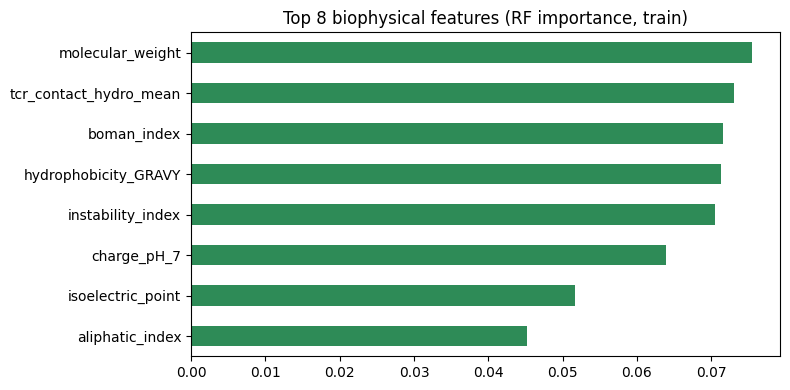

In [6]:
EXCLUDE = {"is_cancer", "Peptide Sequence", "Best HLA Allele"}
BIO_CANDIDATES = [c for c in train_df.columns
                  if c not in EXCLUDE and pd.api.types.is_numeric_dtype(train_df[c])]

_Xsel = (train_df[BIO_CANDIDATES].replace([np.inf, -np.inf], np.nan)
         .fillna(train_df[BIO_CANDIDATES].mean(numeric_only=True)).fillna(0))
_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
_rf.fit(_Xsel, train_df["is_cancer"])
_imp = pd.Series(_rf.feature_importances_, index=BIO_CANDIDATES).sort_values(ascending=False)

TOP8 = _imp.head(N_TOP_BIO).index.tolist()
print("Full importance ranking:")
print(_imp.round(4).to_string())
print(f"\nTOP {N_TOP_BIO} biophysical features used by Stage 1:")
for i, f in enumerate(TOP8, 1):
    print(f"  {i}. {f}  ({_imp[f]:.4f})")

plt.figure(figsize=(8, 4))
_imp.head(N_TOP_BIO)[::-1].plot(kind="barh", color="seagreen")
plt.title(f"Top {N_TOP_BIO} biophysical features (RF importance, train)")
plt.tight_layout(); plt.show()

bio_scaler = StandardScaler().fit(_Xsel[TOP8].values)

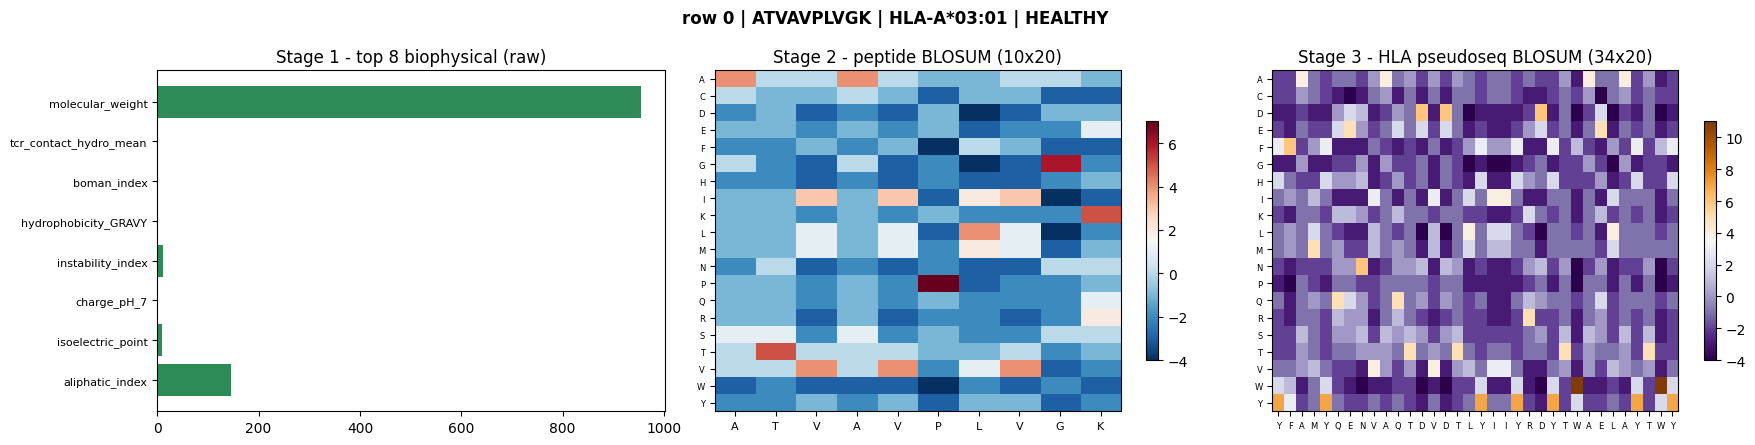

{'peptide': 'ATVAVPLVGK',
 'allele': 'HLA-A*03:01',
 'pseudoseq': 'YFAMYQENVAQTDVDTLYIIYRDYTWAELAYTWY',
 'label': 0,
 'top8': {'molecular_weight': 954.1644,
  'tcr_contact_hydro_mean': 2.05,
  'boman_index': 0.47,
  'hydrophobicity_GRAVY': 1.34,
  'instability_index': 11.28,
  'charge_pH_7': 0.7949,
  'isoelectric_point': 8.7951,
  'aliphatic_index': 146.0}}

In [7]:
def visualize_row(frame, idx):
    row = frame.iloc[idx]
    pep, allele, label = row["Peptide Sequence"], row["Best HLA Allele"], int(row["is_cancer"])
    pep_enc = encode_blosum(pep)
    pseq = pseudo_map[allele]
    mhc_enc = encode_blosum(pseq)
    bio_vals = row[TOP8].astype(float).values

    fig = plt.figure(figsize=(18, 4.5))
    fig.suptitle(f"row {idx} | {pep} | {allele} | {'CANCER' if label else 'HEALTHY'}",
                 fontweight="bold")

    ax1 = fig.add_subplot(1, 3, 1)
    ax1.barh(TOP8[::-1], bio_vals[::-1], color="seagreen")
    ax1.set_title("Stage 1 - top 8 biophysical (raw)")
    ax1.tick_params(axis="y", labelsize=8)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(pep_enc.T, aspect="auto", cmap="RdBu_r")
    ax2.set_yticks(range(20)); ax2.set_yticklabels(_AAS, fontsize=6)
    ax2.set_xticks(range(len(pep))); ax2.set_xticklabels(list(pep), fontsize=8)
    ax2.set_title(f"Stage 2 - peptide BLOSUM ({pep_enc.shape[0]}x20)")
    fig.colorbar(im2, ax=ax2, shrink=0.7)

    ax3 = fig.add_subplot(1, 3, 3)
    im3 = ax3.imshow(mhc_enc.T, aspect="auto", cmap="PuOr_r")
    ax3.set_yticks(range(20)); ax3.set_yticklabels(_AAS, fontsize=6)
    ax3.set_xticks(range(len(pseq))); ax3.set_xticklabels(list(pseq), fontsize=6)
    ax3.set_title(f"Stage 3 - HLA pseudoseq BLOSUM ({mhc_enc.shape[0]}x20)")
    fig.colorbar(im3, ax=ax3, shrink=0.7)

    plt.tight_layout(); plt.show()
    return {"peptide": pep, "allele": allele, "pseudoseq": pseq,
            "label": label, "top8": dict(zip(TOP8, np.round(bio_vals, 4)))}

visualize_row(train_df, 0)

## 3. PyTorch Dataset + DataLoader

Each item returns the three modalities plus the label. Peptides are padded to `MAX_PEP_LEN` with a padding mask; the HLA pseudosequence is fixed length so it needs no padding.

In [8]:
class PeptideMHCDataset(Dataset):
    def __init__(self, frame, scaler):
        self.pep = frame["Peptide Sequence"].tolist()
        self.allele = frame["Best HLA Allele"].tolist()
        self.labels = frame["is_cancer"].astype(int).values
        bio = (frame[TOP8].replace([np.inf, -np.inf], np.nan)
               .fillna(frame[TOP8].mean(numeric_only=True)).fillna(0).values)
        self.bio = scaler.transform(bio).astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        pep_enc = encode_blosum(self.pep[i])                 # (L, 20)
        L = pep_enc.shape[0]
        pep_pad = np.zeros((MAX_PEP_LEN, 20), dtype=np.float32)
        pep_pad[:L] = pep_enc[:MAX_PEP_LEN]
        pad_mask = np.ones(MAX_PEP_LEN, dtype=bool)          # True = padding (ignored by attention)
        pad_mask[:min(L, MAX_PEP_LEN)] = False
        mhc_enc = encode_blosum(pseudo_map[self.allele[i]])  # (34, 20)
        return {
            "bio":      torch.from_numpy(self.bio[i]),
            "pep":      torch.from_numpy(pep_pad),
            "pep_mask": torch.from_numpy(pad_mask),
            "mhc":      torch.from_numpy(mhc_enc),
            "label":    torch.tensor(self.labels[i], dtype=torch.long),
        }

train_ds = PeptideMHCDataset(train_df, bio_scaler)
val_ds   = PeptideMHCDataset(val_df, bio_scaler)
test_ds  = PeptideMHCDataset(test_df, bio_scaler)

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

# verify one batch
_b = next(iter(train_loader))
print("Batch shapes:")
for k, v in _b.items():
    print(f"  {k:9s}: {tuple(v.shape)}  {v.dtype}")
PSEUDO_LEN = len(PSEUDO_POS)

Batch shapes:
  bio      : (128, 8)  torch.float32
  pep      : (128, 11, 20)  torch.float32
  pep_mask : (128, 11)  torch.bool
  mhc      : (128, 34, 20)  torch.float32
  label    : (128,)  torch.int64


## 4. Multimodal model

Three encoders produce one vector each; the peptide cross-attends to the HLA groove (Stage 3); a multi-head attention layer fuses the three stage tokens; a linear head classifies.

In [11]:
class ThreeStageModel(nn.Module):
    def __init__(self, n_bio=N_TOP_BIO, d_model=64, n_heads=4, n_layers=2,
                 max_pep=MAX_PEP_LEN, dropout=0.2):
        super().__init__()
        self.d_model = d_model

        # Stage 1: biophysical MLP -> one token
        self.bio_mlp = nn.Sequential(
            nn.Linear(n_bio, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model), nn.GELU(),
        )

        # Stage 2: peptide BLOSUM -> self-attention transformer (context) ->
        self.pep_proj = nn.Linear(20, d_model)
        self.pep_pos  = nn.Embedding(max_pep, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model, n_heads, d_model * 4,
                                               dropout, batch_first=True)
        self.pep_encoder = nn.TransformerEncoder(enc_layer, n_layers, enable_nested_tensor=False)

        # Stage 3: HLA groove tokens + peptide->MHC cross attention ("fold alongside")
        self.mhc_proj = nn.Linear(20, d_model)
        self.mhc_pos  = nn.Embedding(PSEUDO_LEN, d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        # Fusion: multi-head attention over the 3 stage tokens, then linear head
        self.fusion_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model * 3), nn.Linear(d_model * 3, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, 2),
        )

    def _masked_mean(self, x, pad_mask):
        keep = (~pad_mask).unsqueeze(-1).float()             # (B, L, 1)
        return (x * keep).sum(1) / keep.sum(1).clamp(min=1.0)

    def forward(self, bio, pep, pep_mask, mhc):
        B = bio.size(0)

        # Stage 1
        bio_tok = self.bio_mlp(bio)                          # (B, d)

        # Stage 2
        pos = torch.arange(pep.size(1), device=pep.device).unsqueeze(0)
        pep_x = self.pep_proj(pep) + self.pep_pos(pos)
        pep_x = self.pep_encoder(pep_x, src_key_padding_mask=pep_mask)   # (B, L, d)
        pep_tok = self._masked_mean(pep_x, pep_mask)         # (B, d)

        # Stage 3: peptide residues attend to HLA groove residues
        mpos = torch.arange(mhc.size(1), device=mhc.device).unsqueeze(0)
        mhc_x = self.mhc_proj(mhc) + self.mhc_pos(mpos)      # (B, 34, d)
        cross, _ = self.cross_attn(pep_x, mhc_x, mhc_x, key_padding_mask=None)  # (B, L, d)
        inter_tok = self._masked_mean(cross, pep_mask)       # (B, d)

        # Fusion: 3 tokens -> multi-head attention -> linear
        tokens = torch.stack([bio_tok, pep_tok, inter_tok], dim=1)   # (B, 3, d)
        fused, _ = self.fusion_attn(tokens, tokens, tokens)          # (B, 3, d)
        logits = self.classifier(fused.reshape(B, -1))               # (B, 2)
        return logits

model = ThreeStageModel().to(device)
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

ThreeStageModel(
  (bio_mlp): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): GELU(approximate='none')
  )
  (pep_proj): Linear(in_features=20, out_features=64, bias=True)
  (pep_pos): Embedding(11, 64)
  (pep_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropo

## 5. Quality check / dry run

Push one batch through the model before training: confirm output shape, no NaNs, and that a loss backpropagates.

In [12]:
def to_device(batch):
    return (batch["bio"].to(device), batch["pep"].to(device),
            batch["pep_mask"].to(device), batch["mhc"].to(device),
            batch["label"].to(device))

model.train()
_b = next(iter(train_loader))
bio, pep, pep_mask, mhc, label = to_device(_b)
out = model(bio, pep, pep_mask, mhc)

assert out.shape == (bio.size(0), 2), f"bad output shape {out.shape}"
assert not torch.isnan(out).any(), "NaNs in output"

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(out, label)
loss.backward()
grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)

print("Output shape:", tuple(out.shape))
print("Logits sample:", out[0].detach().cpu().numpy().round(3))
print(f"Loss: {loss.item():.4f}  (ln2 = {np.log(2):.4f} expected at init)")
print(f"Total grad norm: {grad_norm:.4f}  -> backprop OK")
print("Dry run passed - no shape/NaN/grad alarms.")
model.zero_grad()

Output shape: (128, 2)
Logits sample: [-0.323 -0.016]
Loss: 0.6874  (ln2 = 0.6931 expected at init)
Total grad norm: 1.7346  -> backprop OK
Dry run passed - no shape/NaN/grad alarms.


## 6. Training + testing loops

Trains with early-stopping on validation accuracy; saves the best checkpoint; then evaluates on the held-out test set.

In [14]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for batch in loader:
        bio, pep, pep_mask, mhc, label = to_device(batch)
        logits = model(bio, pep, pep_mask, mhc)
        loss = loss_fn(logits, label)
        if train:
            optim.zero_grad(); loss.backward(); optim.step()
        total_loss += loss.item() * label.size(0)
        correct += (logits.argmax(1) == label).sum().item()
        n += label.size(0)
    torch.set_grad_enabled(True)
    return total_loss / n, correct / n

model = ThreeStageModel().to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Adam got to 82% accuracy on seed 42: 
loss_fn = nn.CrossEntropyLoss()

EPOCHS, PATIENCE = 30, 6
best_val, best_state, wait = 0.0, None, 0
ckpt = f"{CACHE_DIR}/threestage_classI_best.pt"
hist = {"train_acc": [], "val_acc": []}

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    hist["train_acc"].append(tr_acc); hist["val_acc"].append(va_acc)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    if va_acc > best_val:
        best_val, best_state, wait = va_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        torch.save(best_state, ckpt)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep} (best val acc {best_val:.4f})")
            break

print(f"\nBest val accuracy: {best_val:.4f}  saved -> {ckpt}")

plt.figure(figsize=(7, 4))
plt.plot(hist["train_acc"], label="train")
plt.plot(hist["val_acc"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Training curve")
plt.tight_layout(); plt.show()

Epoch 01 | train loss 0.4650 acc 0.7564 | val loss 0.3834 acc 0.8230
Epoch 02 | train loss 0.3758 acc 0.8212 | val loss 0.3640 acc 0.8221
Epoch 03 | train loss 0.3658 acc 0.8203 | val loss 0.3635 acc 0.8222
Epoch 04 | train loss 0.3617 acc 0.8216 | val loss 0.3558 acc 0.8262
Epoch 05 | train loss 0.3594 acc 0.8234 | val loss 0.3485 acc 0.8233
Epoch 06 | train loss 0.3571 acc 0.8227 | val loss 0.3620 acc 0.8166
Epoch 07 | train loss 0.3565 acc 0.8225 | val loss 0.3517 acc 0.8245
Epoch 08 | train loss 0.3535 acc 0.8256 | val loss 0.3485 acc 0.8289
Epoch 09 | train loss 0.3527 acc 0.8257 | val loss 0.3476 acc 0.8248
Epoch 10 | train loss 0.3525 acc 0.8252 | val loss 0.3513 acc 0.8253
Epoch 11 | train loss 0.3526 acc 0.8243 | val loss 0.3477 acc 0.8280
Epoch 12 | train loss 0.3491 acc 0.8251 | val loss 0.3464 acc 0.8233
Epoch 13 | train loss 0.3504 acc 0.8257 | val loss 0.3455 acc 0.8262


KeyboardInterrupt: 

In [ ]:
# load best checkpoint and evaluate on the held-out test set
model.load_state_dict(torch.load(ckpt))
model.eval()

all_pred, all_true, all_prob = [], [], []
with torch.no_grad():
    for batch in test_loader:
        bio, pep, pep_mask, mhc, label = to_device(batch)
        logits = model(bio, pep, pep_mask, mhc)
        prob = torch.softmax(logits, 1)[:, 1]
        all_pred += logits.argmax(1).cpu().tolist()
        all_true += label.cpu().tolist()
        all_prob += prob.cpu().tolist()

print("===== TEST SET =====")
print(f"Accuracy:          {accuracy_score(all_true, all_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(all_true, all_pred):.4f}")
print(f"ROC AUC:           {roc_auc_score(all_true, all_prob):.4f}")
print("\nClassification report:")
print(classification_report(all_true, all_pred, target_names=["healthy", "cancer"], digits=4))

cm = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["healthy", "cancer"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["healthy", "cancer"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Test confusion matrix")
plt.tight_layout(); plt.show()

In [15]:
import torch
import numpy as np
# Requires: pip install torch-geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

def create_molecular_graph(pep_seq, mhc_seq, bio_features, label):
    """
    Converts a peptide and MHC sequence into a PyG Graph.
    Uses your existing `encode_blosum` function.
    """
    # 1. Node Features (V)
    pep_nodes = encode_blosum(pep_seq)  # Shape: (L_pep, 20)
    mhc_nodes = encode_blosum(mhc_seq)  # Shape: (34, 20)
    
    # Concatenate nodes: Peptide nodes are indices 0 to L_pep-1. MHC are L_pep to end.
    x = torch.tensor(np.vstack([pep_nodes, mhc_nodes]), dtype=torch.float)
    L_pep = len(pep_seq)
    L_mhc = len(mhc_seq)
    
    edge_indices = []
    edge_attrs = []
    
    # 2. Edges (E) and Edge Attributes
    # Type 0: Peptide Backbone
    for i in range(L_pep - 1):
        edge_indices.extend([[i, i+1], [i+1, i]]) # Undirected
        edge_attrs.extend([[1, 0, 0], [1, 0, 0]]) # One-hot: [Pep, MHC, Interact]
        
    # Type 1: MHC Backbone
    offset = L_pep
    for i in range(L_mhc - 1):
        edge_indices.extend([[offset+i, offset+i+1], [offset+i+1, offset+i]])
        edge_attrs.extend([[0, 1, 0], [0, 1, 0]])
        
    # Type 2: Bipartite Interaction (Peptide to MHC)
    for i in range(L_pep):
        for j in range(L_mhc):
            edge_indices.extend([[i, offset+j], [offset+j, i]])
            edge_attrs.extend([[0, 0, 1], [0, 0, 1]])
            
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    # 3. Global Context (U) & Label
    u = torch.tensor([bio_features], dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)

# Example conversion for the DataLoader
class GraphPeptideDataset(Dataset):
    def __init__(self, df, scaler, pseudo_map):
        super().__init__()
        self.data_list = []
        bio_scaled = scaler.transform(df[TOP8].fillna(0).values)
        
        for idx, row in df.iterrows():
            pep = row["Peptide Sequence"]
            mhc = pseudo_map[row["Best HLA Allele"]]
            label = int(row["is_cancer"])
            bio = bio_scaled[idx]
            
            graph_data = create_molecular_graph(pep, mhc, bio, label)
            self.data_list.append(graph_data)
            
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]

In [23]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class CancerClassificationGNN(nn.Module):
    def __init__(self, node_in_dim=20, edge_in_dim=3, global_in_dim=8, 
                 hidden_dim=64, heads=4, dropout=0.2):
        super().__init__()
        
        # Node Embedding Layer
        self.node_embed = nn.Linear(node_in_dim, hidden_dim)
        
        # Message Passing Layers (Analyzing Nodes + Edges)
        # GATv2Conv allows edge attributes to influence the attention weights
        self.conv1 = GATv2Conv(hidden_dim, hidden_dim, heads=heads, 
                               edge_dim=edge_in_dim, dropout=dropout, concat=False)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim, heads=heads, 
                               edge_dim=edge_in_dim, dropout=dropout, concat=False)
        
        # Global Context Encoder (The MLP from your Stage 1)
        self.global_mlp = nn.Sequential(
            nn.Linear(global_in_dim, hidden_dim), 
            nn.GELU(), 
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.GELU()
        )
        
        # Final Fusion & Classification Head
        # Fuses the pooled Graph Vector with the Tabular Global Vector
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2) # Binary output: [Healthy_Logit, Cancer_Logit]
        )

    def forward(self, data):
        # Extract graph components
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        u, batch = data.u, data.batch
        
        # 1. Process Global Context (U)
        global_repr = self.global_mlp(u) # Shape: (Batch_Size, hidden_dim)
        
        # 2. Process Graph via Message Passing (V + E)
        x = self.node_embed(x)
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        
        # THE FIX: Use F.gelu instead of torch.gelu
        x = F.gelu(x) 
        
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        
        # 3. Readout: Pool variable-sized graphs into fixed-size vectors
        graph_repr = global_mean_pool(x, batch) # Shape: (Batch_Size, hidden_dim)
        
        # 4. Late Fusion & Classification
        fused = torch.cat([graph_repr, global_repr], dim=1) # Shape: (Batch, hidden_dim * 2)
        logits = self.classifier(fused)
        
        return logits

In [19]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# 1. Instantiate the new Graph Datasets 
# (Make sure the GraphPeptideDataset class from the previous step is defined)
train_graph_ds = GraphPeptideDataset(train_df, bio_scaler, pseudo_map)
val_graph_ds   = GraphPeptideDataset(val_df, bio_scaler, pseudo_map)
test_graph_ds  = GraphPeptideDataset(test_df, bio_scaler, pseudo_map)

# 2. Create the PyG DataLoaders
BATCH = 128
train_loader = PyGDataLoader(train_graph_ds, batch_size=BATCH, shuffle=True)
val_loader   = PyGDataLoader(val_graph_ds, batch_size=BATCH, shuffle=False)
test_loader  = PyGDataLoader(test_graph_ds, batch_size=BATCH, shuffle=False)

# Optional: Verify the batch output
_b = next(iter(train_loader))
print("New PyG Batch:", _b)
print("Type:", type(_b))

/var/folders/l8/spvmzwbs7bs1x01lz_wgpmw40000gn/T/ipykernel_7483/3338900729.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  u = torch.tensor([bio_features], dtype=torch.float)


New PyG Batch: DataBatch(x=[5535, 20], edge_index=[2, 91002], edge_attr=[91002, 3], y=[128], u=[128, 8], batch=[5535], ptr=[129])
Type: <class 'abc.DataBatch'>


In [24]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(train)
    
    for batch in loader:
        # 1. Move the entire PyG Batch object to the device
        batch = batch.to(device)
        
        # 2. Pass the batch to the GNN
        logits = model(batch)
        
        # 3. Calculate loss using batch.y (the labels)
        loss = loss_fn(logits, batch.y)
        
        if train:
            optim.zero_grad()
            loss.backward()
            optim.step()
            
        # 4. Accumulate metrics
        total_loss += loss.item() * batch.y.size(0)
        correct += (logits.argmax(1) == batch.y).sum().item()
        n += batch.y.size(0)
        
    torch.set_grad_enabled(True)
    return total_loss / n, correct / n

# Initialize the GNN instead of the old ThreeStageModel
model = CancerClassificationGNN().to(device)

# Adam optimizer usually works well for GNNs, though you might need to tune the LR
optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

EPOCHS, PATIENCE = 30, 6
best_val, best_state, wait = 0.0, None, 0
ckpt = f"{CACHE_DIR}/gnn_cancer_model_best.pt"
hist = {"train_acc": [], "val_acc": []}

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    hist["train_acc"].append(tr_acc); hist["val_acc"].append(va_acc)
    
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    
    if va_acc > best_val:
        best_val, best_state, wait = va_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        torch.save(best_state, ckpt)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep} (best val acc {best_val:.4f})")
            break

print(f"\nBest val accuracy: {best_val:.4f}  saved -> {ckpt}")

# Plotting remains exactly the same
plt.figure(figsize=(7, 4))
plt.plot(hist["train_acc"], label="train")
plt.plot(hist["val_acc"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("GNN Training curve")
plt.tight_layout(); plt.show()

Epoch 01 | train loss 0.6231 acc 0.6250 | val loss 0.5130 acc 0.7378
Epoch 02 | train loss 0.4467 acc 0.7757 | val loss 0.4208 acc 0.7842
Epoch 03 | train loss 0.4033 acc 0.8016 | val loss 0.4062 acc 0.7943
Epoch 04 | train loss 0.3997 acc 0.8005 | val loss 0.3940 acc 0.8051
Epoch 05 | train loss 0.3854 acc 0.8111 | val loss 0.3884 acc 0.8125
Epoch 06 | train loss 0.3832 acc 0.8097 | val loss 0.4000 acc 0.8007
Epoch 07 | train loss 0.3774 acc 0.8166 | val loss 0.3685 acc 0.8247
Epoch 08 | train loss 0.3732 acc 0.8175 | val loss 0.3646 acc 0.8265
Epoch 09 | train loss 0.3765 acc 0.8142 | val loss 0.3635 acc 0.8239
Epoch 10 | train loss 0.3691 acc 0.8189 | val loss 0.3721 acc 0.8131


KeyboardInterrupt: 